# **Trabajo IDIF: Optimización de sistemas de inferencia difusa para problemas de control**

Mi idea es simular un sistema de una bola en un tubo vertical, que se quiere dejar fija a una cierta altura. La bola sufre una cierta atracción gravitatoria, y quizá una cierta interferencia aleatoria, y el sistema controla una fuerza ascendente sobre la pelota. 

Los parámetros de entrada son la posición y el desplazamiento desde el último instante. La función de pérdida es la distancia media a la altura deseada a lo largo del tiempo de simulación (MAE). 

Para realizar esta optimización, usaré Enjambre de Partículas (PSO) y un algoritmo genético puro (GA).

In [1]:
import numpy as np
from matplotlib import cm
import matplotlib.pyplot as plt
import pickle
from FISControlOpt import *

Diseño la simulación, que es bastante sencilla. El experimento que se pretende simular es el siguiente:

Se inserta una bola en un cilindro vertical, el cual tiene un ventilador en la parte inferior. Se quiere mantener la bola a una cierta altura. El controlador tiene información de la posición de la bola y de su velocidad en cada instante, y controla la potencia del ventilador. Sin embargo, hay un cierto nivel de ruido en el sistema, con lo que la fuerza realizada hacia arriba no coincide exactamente con la que determina el controlador. 

Para evaluar la actuación del controlador se usa como función de pérdida el error medio a lo largo del tiempo de simulación, sumando, con un coeficiente bajo, la fuerza media aplicada durante el tiempo de simulación. Este segundo término pretende que el controlador no sea brusco innecesariamente, minimizando el gasto de energía del ventilador, y evitando oscilaciones entorno al punto deseado.

Para simular esto, uso la siguiente función.

---

## Controlador PID

Me es muy útil a nivel comparativo, así que lo hago aquí al principio.

In [63]:
import numpy as np

def simular_tubo_pid(Kp, Ki, Kd, altura_deseada=10.0, coef_fuerza=0.05, coef_suavidad=0.05, 
                     pasos_tiempo=100, tiempo_final=5, init=(0,0), noisy=True, noise=None, 
                     penalizar_fuerza=True, penalizar_suavidad=True, full_output=False):
    """
    Simula la física de la bola controlada por un PID clásico.
    Parámetros PID:
    - Kp: Ganancia Proporcional
    - Ki: Ganancia Integral
    - Kd: Ganancia Derivativa
    """

    dt = tiempo_final / pasos_tiempo
    
    y = init[0]       # Posición inicial
    v = init[1]       # Velocidad inicial
    y_prev = y - v*dt # Posición en el instante anterior
        
    m = 1.0      # Masa de la bola (kg)
    g = 9.81     # Gravedad (m/s^2)
    
    # --- VARIABLES ESTADO PID ---
    error_integral = 0.0
    error_previo = altura_deseada - y
    
    historial_y = []
    historial_fuerza = []
    if full_output:
        historial_velocidad = []

    for este_paso in range(pasos_tiempo):
        # --- CÁLCULO DEL ERROR PID ---
        # Error actual (Setpoint - Proceso)
        error = altura_deseada - y
        
        # Acumulación para el término Integral
        error_integral += error * dt
        
        # Tasa de cambio para el término Derivativo
        derivada_error = (error - error_previo) / dt
        
        # --- CÁLCULO DE LA FUERZA PID ---
        fuerza_pid = (Kp * error) + (Ki * error_integral) + (Kd * derivada_error)
        
        # Feed-forward: sumamos el peso base para cancelar la gravedad en estado estacionario
        fuerza_base = m * g 
        
        # La fuerza total no puede ser negativa (el ventilador solo empuja hacia arriba)
        fuerza = max(0, fuerza_base + fuerza_pid)
        
        historial_fuerza.append(fuerza)
        
        # Actualizamos el error previo para la siguiente iteración
        error_previo = error

        # --- PERTURBACIÓN Y FÍSICA ---
        if full_output: historial_velocidad.append(v)

        if noisy:
            if noise is None:
                interferencia = np.random.normal(0, 3)
            elif len(noise) == pasos_tiempo:
                interferencia = noise[este_paso]
            else: 
                interferencia = 0
        else: 
            interferencia = 0
        
        # Segunda Ley de Newton: Fuerza Neta = Masa * Aceleración
        # (La gravedad tira hacia abajo, la fuerza hacia arriba, más ruido)
        fuerza_neta = fuerza - (m * g) + interferencia
        aceleracion = fuerza_neta / m
        
        # Actualización de cinemática (Método de Euler)
        v += aceleracion * dt
        y_prev = y
        y += v * dt
        
        # Restricción del suelo del tubo
        if y < 0:
            y = 0.0
            v = -0.3 * v  # Rebote inelástico
            
        historial_y.append(y)
        
    # --- FUNCIÓN DE PÉRDIDA ---
    perdida = np.mean(np.abs(np.array(historial_y) - altura_deseada))
    
    if penalizar_fuerza:
        perdida += coef_fuerza * np.mean(np.abs(np.array(historial_fuerza)))
    if penalizar_suavidad:
        perdida += coef_suavidad * np.mean(np.abs(np.diff(historial_fuerza)))

    if full_output: 
        return perdida, historial_y, historial_velocidad, historial_fuerza
    else:
        return perdida, historial_y

In [ ]:
cond_inic = [(p,v) for p in [0, 10, 20] for v in [-10, 0, 10]]

kp_range = np.linspace(5, 40, 6)
ki_range = np.linspace(0, 10, 6)
kd_range = np.linspace(0, 20, 6)

mejor_perdida = float('inf')
mejores_params = {}

for kp in kp_range:
    for ki in ki_range:
        for kd in kd_range:
            perdida = 0
            for init in cond_inic:
                perdida_caso, historial_y = simular_tubo_pid(Kp= kp, Ki = ki, Kd=kd, noisy = True, init = init)
                perdida += perdida_caso/len(cond_inic)
            
            if perdida < mejor_perdida:
                mejor_perdida = perdida
                mejores_params = {'Kp': kp, 'Ki': ki, 'Kd': kd}

print(f"Mejor pérdida: {mejor_perdida:.4f}")
print(f"Mejores parámetros: {mejores_params}")

Mejor pérdida: 2.2883
Mejores parámetros: {'Kp': np.float64(12.0), 'Ki': np.float64(0.0), 'Kd': np.float64(8.0)}


2.332180667425265


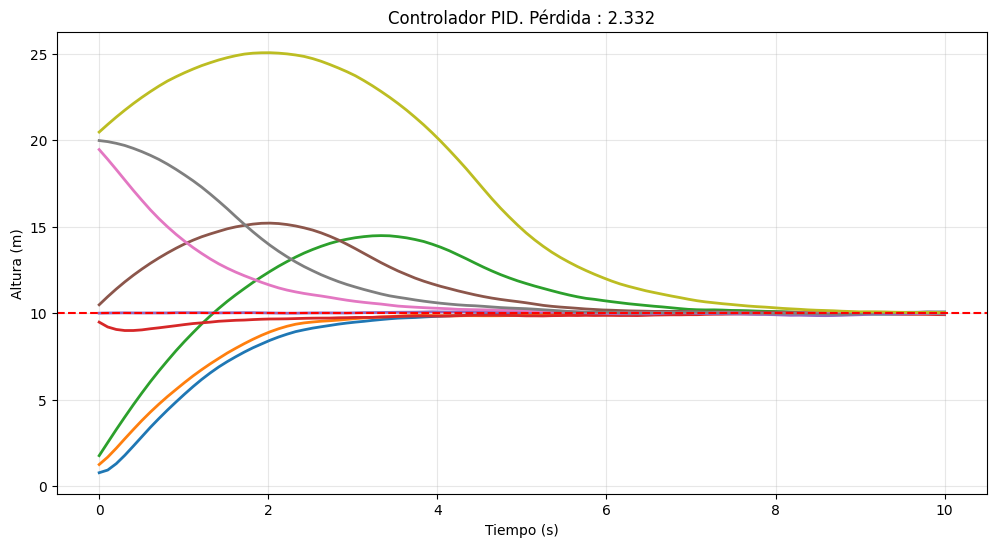

In [66]:
cond_inic = [(p,v) for p in [1, 10, 20] for v in [-10, 0, 10]]
perdida_tot = 0
trayectorias = []
for init in cond_inic:
    perdida, historial_y = simular_tubo_pid(Kp= 12, Ki = 0, Kd=8, noisy = True, init = init)
    perdida_tot += perdida/len(cond_inic)
    trayectorias.append(historial_y)


print(perdida_tot)
tiempo = np.linspace(0, 10, 100)
plt.figure(figsize = (12,6))
for trayectoria in trayectorias:
    plt.plot(tiempo, trayectoria, lw=2)
    
    plt.title(f"Controlador PID. Pérdida : {perdida_tot:.3f}", fontsize=12)
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Altura (m)")
plt.axhline(y=10.0, color='red', linestyle='--', label="Objetivo (10 m)")
plt.grid(True, alpha=0.3)
plt.show()

Los sistemas de inferencia borrosa que se usan son sistemas de Sugeno de orden 0. Los conjuntos borrosos asociados a las hipotéticas etiquetas linguísticas usan funciones de pertenencia gaussianas (las triangulares daban lugar a resultados peores, menos suaves) y se consideran todas las combinaciones de antecendetes posibles para construir reglas. Esto hace que, en realidad, un FIS de este tipo, con $n_p$ valores linguísticos para la posición de la bola y $n_v$ para la velocidad se pueda resumir a $2n_p + 2n_v + n_p n_v$ parámetros reales. Para $n_p = n_v = 3$ esto son 21 parámetros, y para $n_p = n_v = 5$, son 45 parámetros. 

Por tanto, buscar el FIS bajo estas condiciones es un problema de minimización de $F: \mathbb{R}^N \rightarrow \mathbb{R}_+ $, lo cual puede llevar a pensar en utilizar algún algoritmo tipo descenso del gradiente, Sin embargo, tanto el ruido como la recursividad dificultan aplicar este tipo de algoritmos directamente, y lo único verdaderamente viable es utilizar un Gradient Descent Through Time (GDTT), que es costoso computacionalmente, y bastante complejo a nivel de implementación. Por tanto, opto por otros dos algoritmos de implementación más sencilla. Estos son la optimización por enjambre de partículas y un algoritmo genético clásico. 

El primero pretende tomar un conjunto de FIS como puntos en $\mathbb{R}^N$ y desplazarlos a imitación de "un rebaño buscando los partos más verdes". Cada FIS recuerda cuáles son los mejores parámetros que ha tomado (p_best) y los mejores que ha tomado cualquiera del rebaño (g_best), y conserva una inercia correspondiente al último movimiento que ha hecho. La actualización de los parámetros es:

$$ x_{n+1} = x_n + \alpha_p \cdot p\_best + \alpha_g  \cdot g\_best + \omega (x_n -x_{n-1})$$

Siendo $\alpha_p, \alpha_g, \omega >0$ parámetros que se van modificando al pasar las iteraciones. Inicialmente es interesante que la inercia y la individualidad sean altas, para que haya más exploración del espacio de soluciones, y al final el término dominante debería ser el grupal, que permite explotar más la mejor región encontrada.

El segundo algoritmo es el genético. El concepto de algoritmo genético es ampliamente conocido, y está inspirado en la mecánica de la selección natural y la genética poblacional. Se comienza con una población inicial, cuya actuación se evalúa inicialmente. Se los ordena de mejor a peor, y unos pocos de los primeros se mantienen intactos en la siguiente generación. El resto de la siguiente generación son "hijos" de la generación anterior. Para crear cada uno de estos, se toman 3 elementos de la generación anterior y se elige al mejor de entre ellos, para el primer progenitor, y se repite para el segundo. Para cada parámetro del FIS resultante, se hace la combinación lineal de ambos progenitores, ponderados por un parámetro aleatorio que favorece al que mejor evaluación tenga. 

$$x_i = p_i x_i^1 + (1-p_i)x_i^2, \quad \forall i = 1, ..., N$$

Con toda la generación nueva se realizan las mutaciones. Con una pequeña probabilidad, se cambia un parámetro de forma aleatoria. La probabilidad de mutación y la fuerza de esa mutación van disminuyendo con las iteraciones.

Iniciando PSO para SugenoFIS (3x3 reglas | 21 dim | 100 particulas | 50 iteraciones)
Iteración 5/50 | Error: 4.671 m | Estancado: 0/30
Iteración 10/50 | Error: 3.005 m | Estancado: 0/30
Iteración 15/50 | Error: 2.798 m | Estancado: 2/30
Iteración 20/50 | Error: 2.708 m | Estancado: 0/30
Iteración 25/50 | Error: 2.588 m | Estancado: 1/30
Iteración 30/50 | Error: 2.542 m | Estancado: 0/30
Iteración 35/50 | Error: 2.515 m | Estancado: 2/30
Iteración 40/50 | Error: 2.506 m | Estancado: 0/30
Iteración 45/50 | Error: 2.499 m | Estancado: 1/30
Iteración 50/50 | Error: 2.496 m | Estancado: 0/30


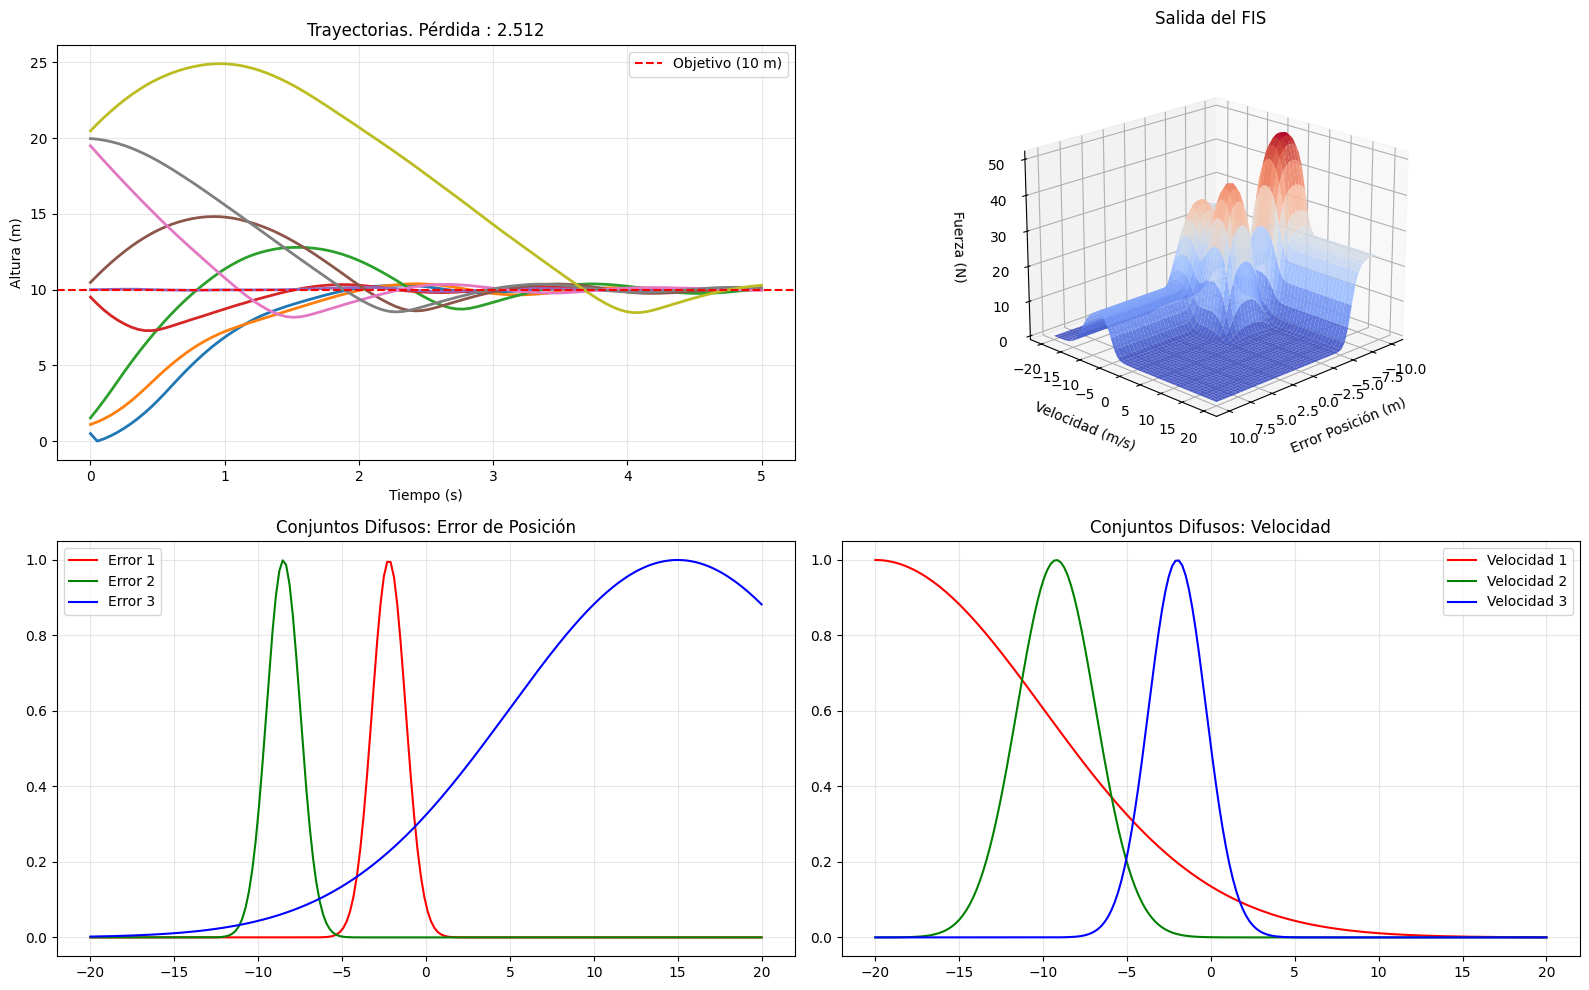

In [4]:
# Entrenar el sistema con PSO
# Nota: Para obtener resultados buenos lo ideal sería incluir al menos unas 500 partículas y 100 iteraciones, pero eso hace que tarde en ejecutar.

init = [(p, v) for p in [1, 10, 20] for v in [-10, 0, 10]]
mejor_fis_PSO, historial = optimizar_pso(n_e=3, n_v=3, num_particulas=100, num_iteraciones=50, init=init, noisy  = False)
graficar_fis_limpio(mejor_fis_PSO, init)

Iniciando AG (21 dim | Población: 100 | Generaciones: 100)
Generación 5/100 | Mejor Pérdida: 9.711 
Generación 10/100 | Mejor Pérdida: 8.060 
Generación 15/100 | Mejor Pérdida: 4.101 
Generación 20/100 | Mejor Pérdida: 3.337 
Generación 25/100 | Mejor Pérdida: 3.082 
Generación 30/100 | Mejor Pérdida: 2.912 
Generación 35/100 | Mejor Pérdida: 2.833 
Generación 40/100 | Mejor Pérdida: 2.781 
Generación 45/100 | Mejor Pérdida: 2.701 
Generación 50/100 | Mejor Pérdida: 2.645 
Generación 55/100 | Mejor Pérdida: 2.602 
Generación 60/100 | Mejor Pérdida: 2.534 
Generación 65/100 | Mejor Pérdida: 2.514 
Generación 70/100 | Mejor Pérdida: 2.474 
Generación 75/100 | Mejor Pérdida: 2.463 
Generación 80/100 | Mejor Pérdida: 2.457 
Generación 85/100 | Mejor Pérdida: 2.450 
Generación 90/100 | Mejor Pérdida: 2.438 
Generación 95/100 | Mejor Pérdida: 2.435 
Generación 100/100 | Mejor Pérdida: 2.426 


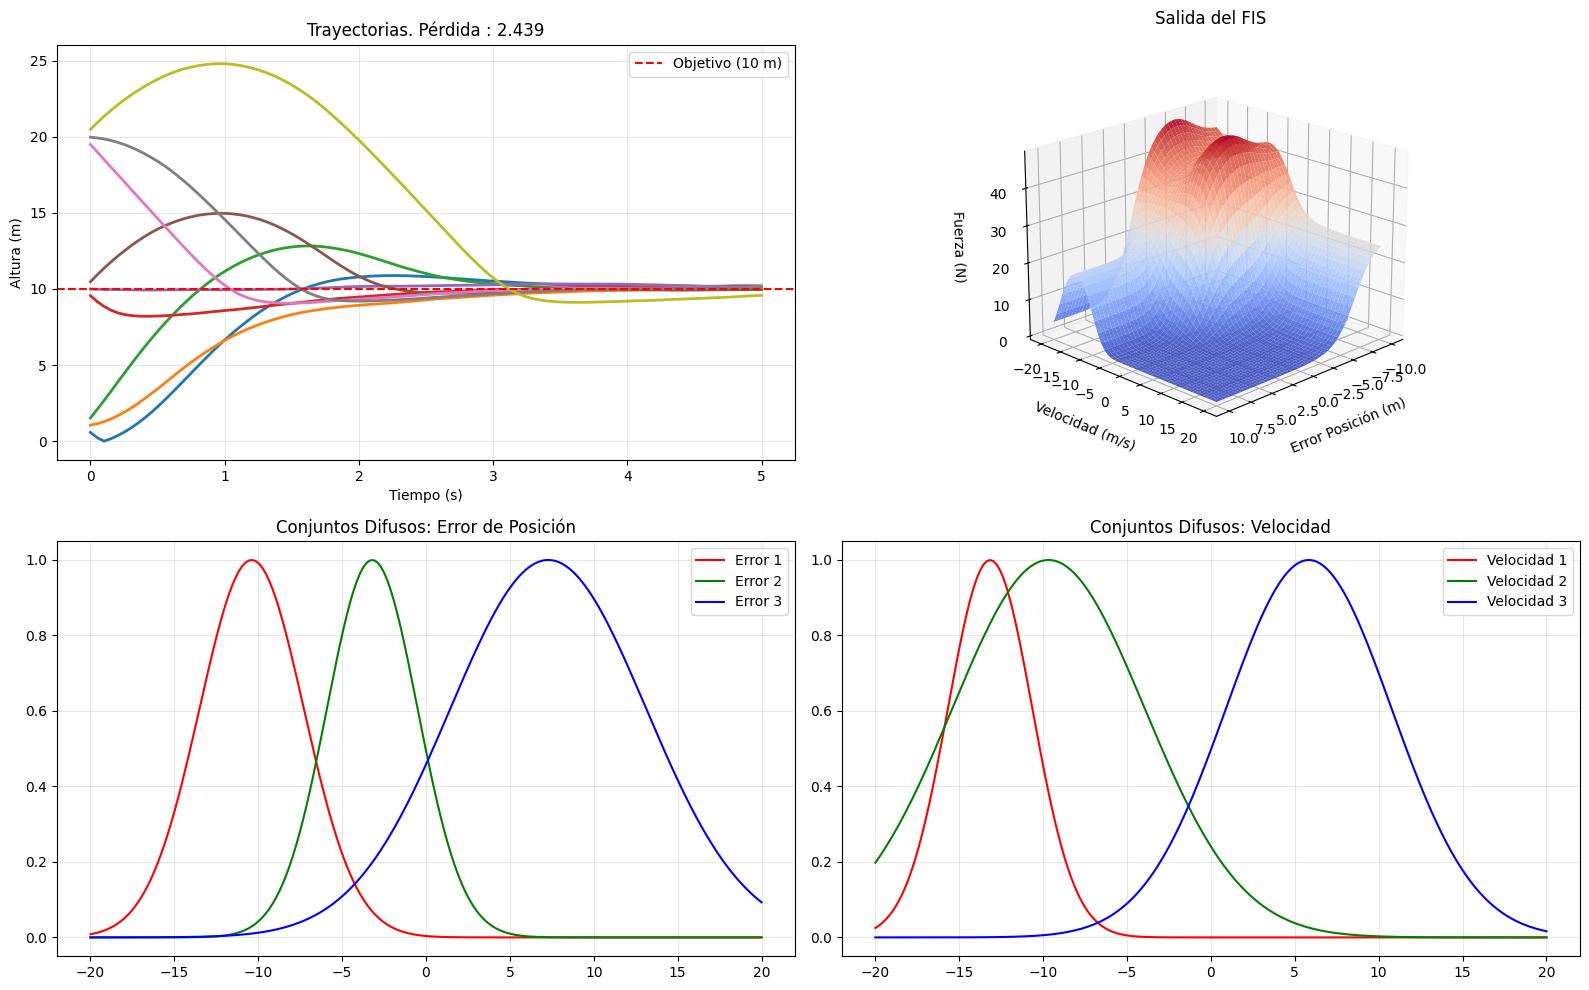

In [2]:
# Entrenar el sistema con GA
# Nota: Para obtener resultados buenos lo ideal sería incluir al menos unas 500 partículas y 200 iteraciones, 
# pero eso hace que tarde mucho en ejecutar (no menos de media hora larga).

init= [(p, v) for p in [1, 10, 20] for v in [-10, 0, 10]]
mejor_fis_GA, historial = optimizar_ga(n_e=3, n_v=3, tamano_poblacion = 100, num_generaciones=100, tasa_mutacion = 0.1,
                                        fuerza_mutacion_base = 0.1, elitismo = 10, init=init, noisy= False)
graficar_fis_limpio(mejor_fis_GA, init)

Iniciando PSO para SugenoFIS (5x5 reglas | 45 dim | 200 particulas | 100 iteraciones)
Iteración 5/100 | Error: 5.822 m | Estancado: 0/30
Iteración 10/100 | Error: 4.061 m | Estancado: 0/30
Iteración 15/100 | Error: 2.961 m | Estancado: 0/30
Iteración 20/100 | Error: 2.673 m | Estancado: 0/30
Iteración 25/100 | Error: 2.609 m | Estancado: 1/30
Iteración 30/100 | Error: 2.565 m | Estancado: 2/30
Iteración 35/100 | Error: 2.521 m | Estancado: 0/30
Iteración 40/100 | Error: 2.493 m | Estancado: 0/30
Iteración 45/100 | Error: 2.484 m | Estancado: 0/30
Iteración 50/100 | Error: 2.476 m | Estancado: 0/30
Iteración 55/100 | Error: 2.468 m | Estancado: 0/30
Iteración 60/100 | Error: 2.467 m | Estancado: 4/30
Iteración 65/100 | Error: 2.463 m | Estancado: 0/30
Iteración 70/100 | Error: 2.463 m | Estancado: 2/30
Iteración 75/100 | Error: 2.463 m | Estancado: 2/30
Iteración 80/100 | Error: 2.462 m | Estancado: 1/30
Iteración 85/100 | Error: 2.422 m | Estancado: 0/30
Iteración 90/100 | Error: 2.413

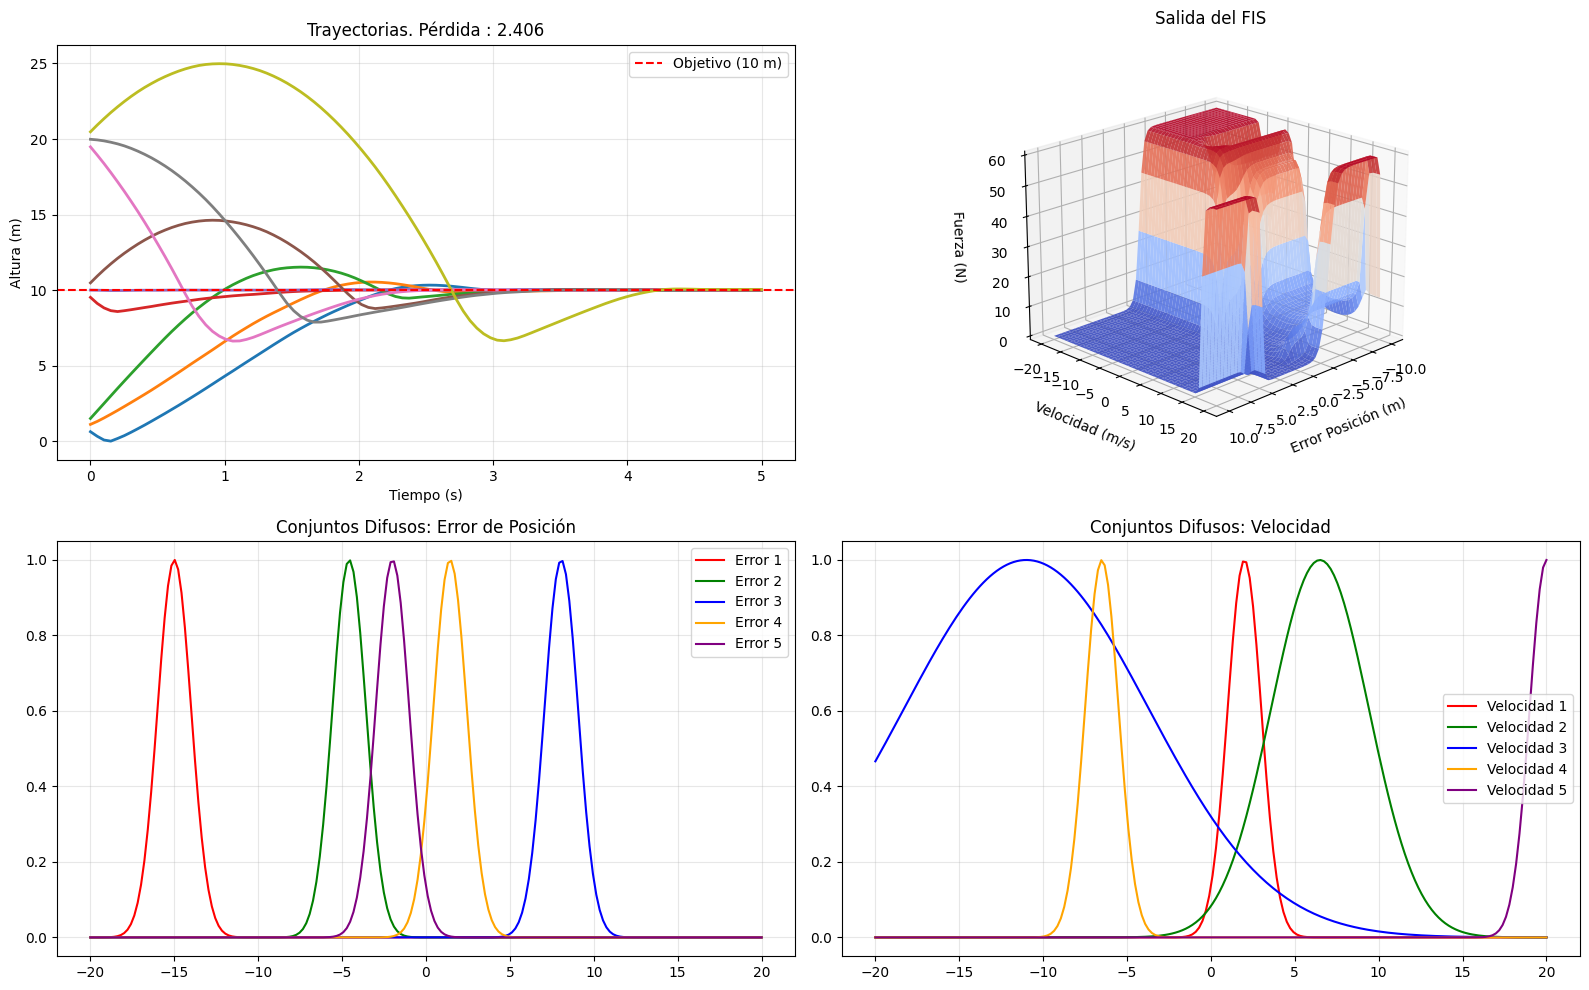

In [7]:
# Entrenar el sistema con PSO
init = [(p, v) for p in [1, 10, 20] for v in [-10, 0, 10]]
mejor_fis_PSO, historial = optimizar_pso(n_e=5, n_v=5, num_particulas=200, num_iteraciones=100, init=init, noisy = False)
graficar_fis_limpio(mejor_fis_PSO, init)

Iniciando AG (45 dim | Población: 100 | Generaciones: 200)
Generación 5/200 | Mejor Pérdida: 16.796 
Generación 10/200 | Mejor Pérdida: 8.283 
Generación 15/200 | Mejor Pérdida: 5.183 
Generación 20/200 | Mejor Pérdida: 3.775 
Generación 25/200 | Mejor Pérdida: 3.230 
Generación 30/200 | Mejor Pérdida: 2.986 
Generación 35/200 | Mejor Pérdida: 2.898 
Generación 40/200 | Mejor Pérdida: 2.799 
Generación 45/200 | Mejor Pérdida: 2.737 
Generación 50/200 | Mejor Pérdida: 2.676 
Generación 55/200 | Mejor Pérdida: 2.619 
Generación 60/200 | Mejor Pérdida: 2.579 
Generación 65/200 | Mejor Pérdida: 2.543 
Generación 70/200 | Mejor Pérdida: 2.522 
Generación 75/200 | Mejor Pérdida: 2.483 
Generación 80/200 | Mejor Pérdida: 2.470 
Generación 85/200 | Mejor Pérdida: 2.429 
Generación 90/200 | Mejor Pérdida: 2.427 
Generación 95/200 | Mejor Pérdida: 2.411 
Generación 100/200 | Mejor Pérdida: 2.402 
Generación 105/200 | Mejor Pérdida: 2.392 
Generación 110/200 | Mejor Pérdida: 2.381 
Generación 115

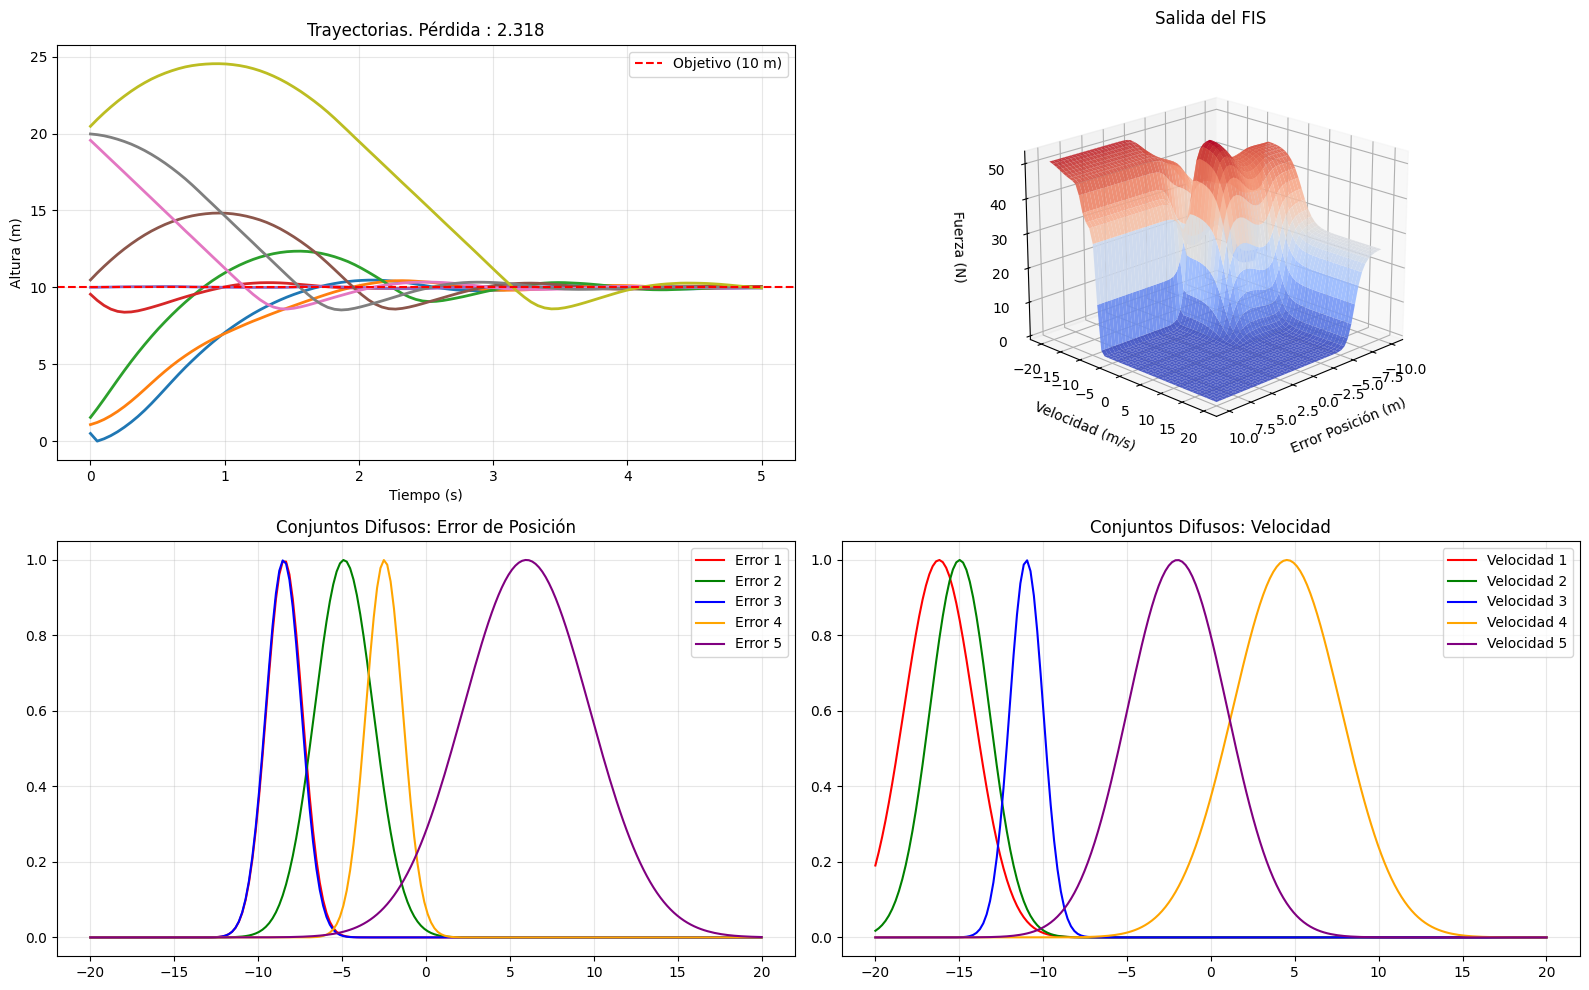

In [9]:
init = [(p, v) for p in [1, 10, 20] for v in [-10, 0, 10]]
mejor_fis_GA, historial = optimizar_ga(n_e=5, n_v=5, tamano_poblacion=100, num_generaciones=200, tasa_mutacion = 0.1,
                                        fuerza_mutacion_base = 0.1, elitismo = 10, init=init, noisy = False)
graficar_fis_limpio(mejor_fis_GA, init)

A continuación hay una ejecución del caso combinado. Se ejecuta 50 veces el algoritmo genético con población e iteraciones reducidas, solo evaluando en algunos casos concretos, y se usa esa población para, de nuevo, un genético, tampoco demasiado grande pero con todos los casos. Para la explotación final se usa un PSO. 

Los resultados son muy buenos, y es relativamente rápido en comparación con otros algoritmos para obtener resultados similares. En cierta manera el hecho de ejecutar varios genéticos pequeños explora de forma muy amplia, el genético grande utiliza esa población previa para "uniformizar" esa variedad, y el PSO explota las mejores soluciones.

1/25 individuo inicial
Iniciando AG (21 dim | Población: 20 | Generaciones: 50)
Generación 5/50 | Mejor Pérdida: 25.217 
Generación 10/50 | Mejor Pérdida: 20.368 
Generación 15/50 | Mejor Pérdida: 17.466 
Generación 20/50 | Mejor Pérdida: 12.391 
Generación 25/50 | Mejor Pérdida: 6.453 
Generación 30/50 | Mejor Pérdida: 6.245 
Generación 35/50 | Mejor Pérdida: 5.968 
Generación 40/50 | Mejor Pérdida: 5.424 
Generación 45/50 | Mejor Pérdida: 5.203 
Generación 50/50 | Mejor Pérdida: 5.064 
2/25 individuo inicial
Iniciando AG (21 dim | Población: 20 | Generaciones: 50)
Generación 5/50 | Mejor Pérdida: 6.552 
Generación 10/50 | Mejor Pérdida: 4.657 
Generación 15/50 | Mejor Pérdida: 3.243 
Generación 20/50 | Mejor Pérdida: 2.663 
Generación 25/50 | Mejor Pérdida: 2.492 
Generación 30/50 | Mejor Pérdida: 2.299 
Generación 35/50 | Mejor Pérdida: 2.212 
Generación 40/50 | Mejor Pérdida: 2.175 
Generación 45/50 | Mejor Pérdida: 2.140 
Generación 50/50 | Mejor Pérdida: 2.101 
3/25 individuo ini

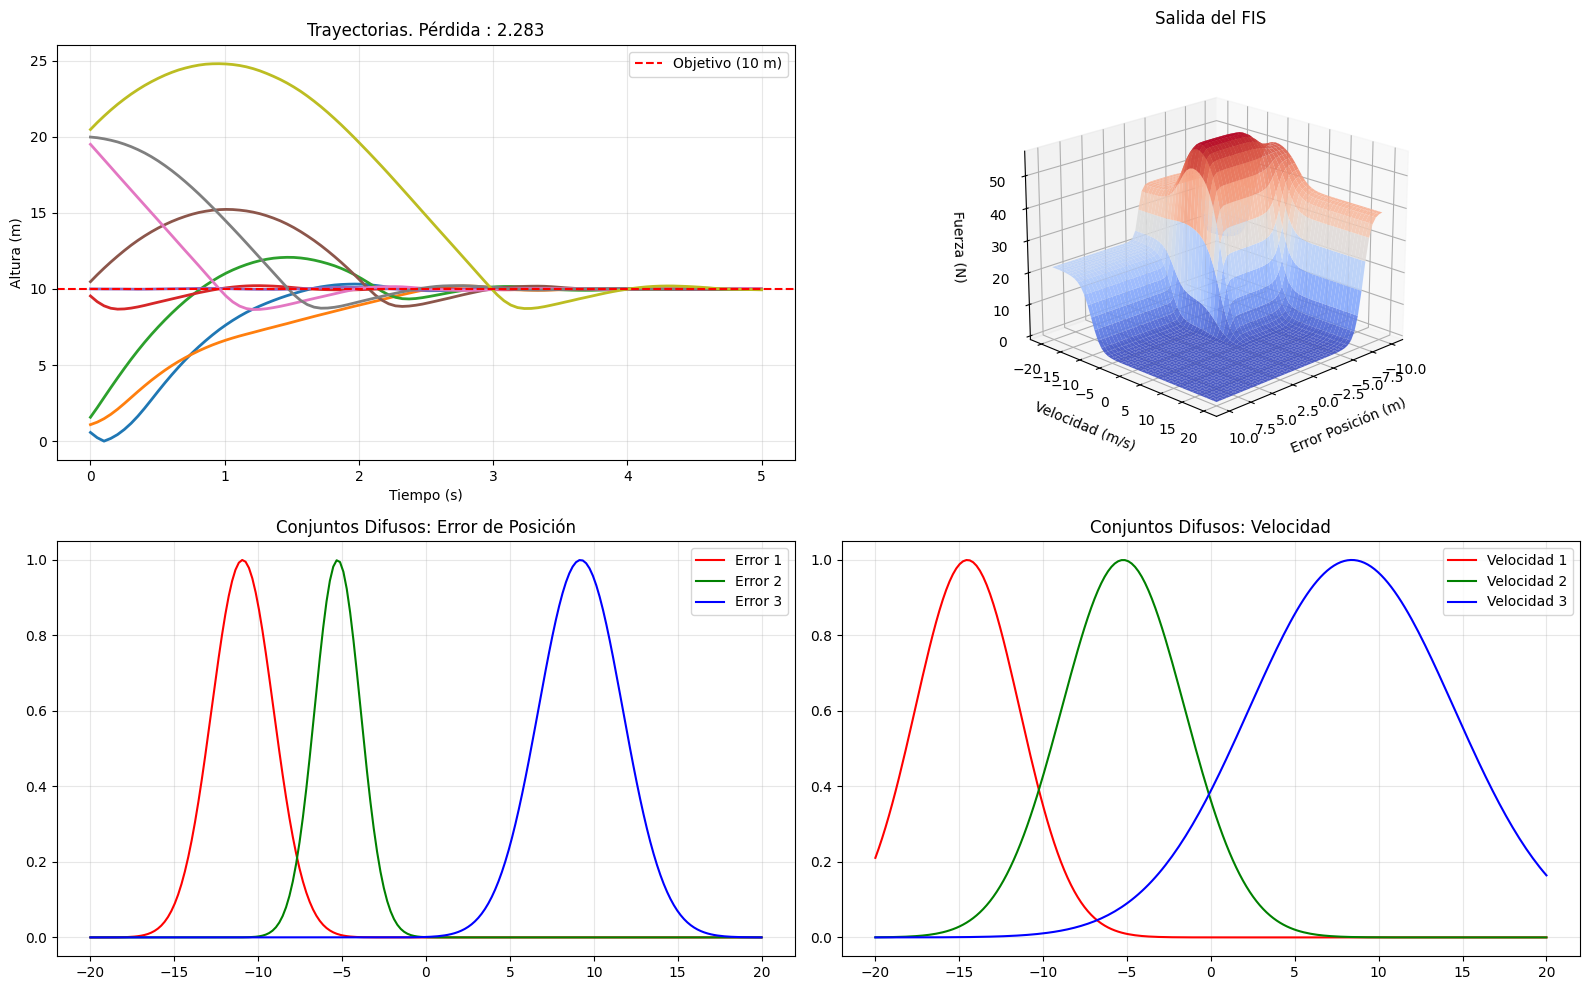

In [10]:
import random

dim = 3
init_graf = [(p,v) for p in [1, 10, 20] for v in [-10, 0, 10]]

fis_favorables = []
for i in range(25):
    print(f"{i+1}/25 individuo inicial")
    fis_AG, _ = optimizar_ga(n_e=dim, n_v=dim, tamano_poblacion = 20, num_generaciones=50, tasa_mutacion = 0.1,
                                        fuerza_mutacion_base = 0.1, elitismo = 2, init=random.sample(init_graf, 3), noisy = False)
    fis_favorables.append(fis_AG)

fis_1, historial, poblacion = optimizar_ga(n_e=dim, n_v=dim, tamano_poblacion=200, num_generaciones= 200, 
                                        init=init_graf, elitismo = 2, return_poblacion= True,
                                        noisy = False, fis_iniciales=fis_favorables)

fis_para_pso = [fis_desde_particula(particula, dim, dim) for particula in poblacion]

fis_final, historial = optimizar_pso(n_e=dim, n_v=dim, num_particulas=400, num_iteraciones= 200, 
                                        init=init_graf,
                                        noisy = False, fis_iniciales = fis_para_pso)


with open('FIS_final_9x9.pkl', 'wb') as archivo:
    pickle.dump(fis_final, archivo)

graficar_fis_limpio(fis_final, init = init_graf)